In [23]:
# Ricarica automaticamente i moduli se li modifichi (FONDAMENTALE mentre lavori)
%load_ext autoreload
%autoreload 2

import sys
import os
# Aggiunge la cartella principale al path per trovare 'src'
sys.path.append(os.path.abspath('..'))

from src.strategy.simulation import RaceSimulation
from src.utils.visualization import plot_strategy_comparison

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
# 1. Inizializza il Simulatore
sim = RaceSimulation()

# 2. Lancia le simulazioni (calcoli puri)
print("Simulazione Piano A in corso...")
laps_a, times_a = sim.run_single_strategy("MEDIUM", pit_lap=20)

print("Simulazione Piano B in corso...")
laps_b, times_b = sim.run_single_strategy("MEDIUM", pit_lap=15)

Simulazione Piano A in corso...


AttributeError: 'RaceSimulation' object has no attribute 'run_single_strategy'

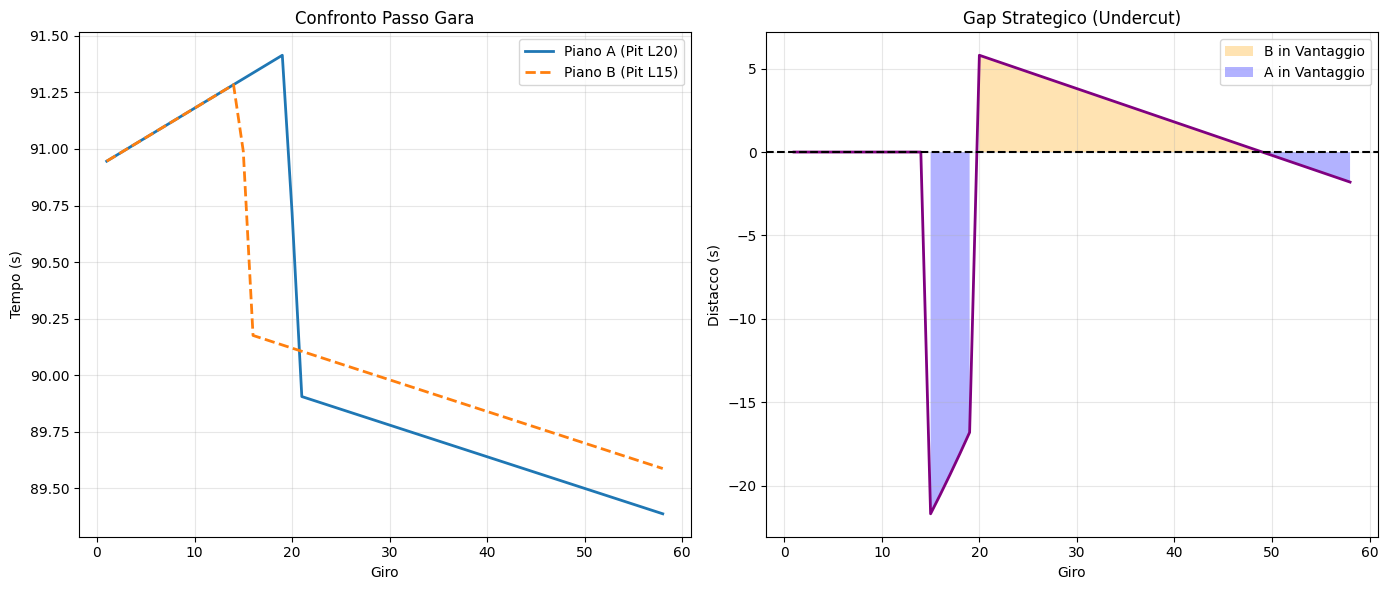

In [ ]:
# 3. Genera i grafici (usando la funzione pulita in utils)
plot_strategy_comparison(laps_a, times_a, laps_b, times_b)

In [25]:
from src.data.historical import get_austin_2024_start_conditions
from src.strategy.austin_validation import AustinSimulator
import matplotlib.pyplot as plt

In [26]:
# 1. Scarichiamo la griglia reale di Austin 2024
print("Recupero dati storici Austin 2024...")
grid_data = get_austin_2024_start_conditions()
print("\n--- GRIGLIA DI PARTENZA REALE ---")
display(grid_data) # Se sei su Jupyter, altrimenti usa print(grid_data)

Recupero dati storici Austin 2024...
⬇️ Scaricamento dati Austin 2024 (potrebbe richiedere un minuto)...


core           INFO 	Loading data for United States Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['16', '55', '1', '4', '81', '63', '11', '27', '30', '43', '20', '10', '14', '22', '18', '23', '77', '31', '24', '44']



--- GRIGLIA DI PARTENZA REALE ---


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/fastf1/core.py:3183: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


,Driver,GridPosition,StartCompound,StartTyreAge
0,LEC,4.0,MEDIUM,0
1,SAI,3.0,MEDIUM,0
2,VER,2.0,MEDIUM,0
3,NOR,1.0,MEDIUM,0
4,PIA,5.0,MEDIUM,0


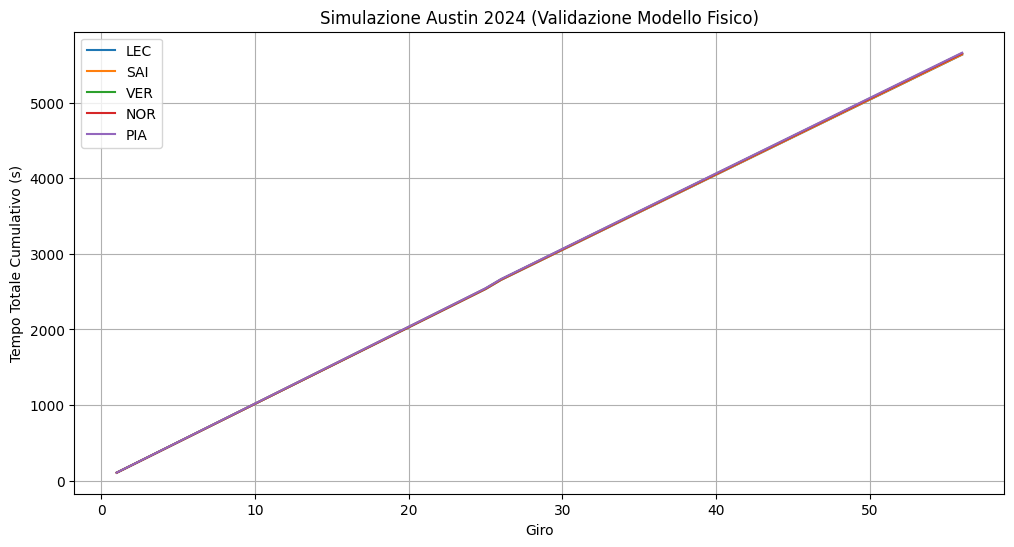


--- CLASSIFICA PREDETTA (Basata su Fisica 20 Variabili) ---
1. LEC - Tempo: 5636.36s
2. SAI - Tempo: 5638.86s
3. NOR - Tempo: 5652.26s
4. VER - Tempo: 5655.36s
5. PIA - Tempo: 5661.86s

--- REALTÀ AUSTIN 2024 ---
1. LEC (Vincitore)
2. SAI
3. VER


In [27]:
# 2. Simuliamo la gara per ogni pilota
sim = AustinSimulator()
results = {}

plt.figure(figsize=(12, 6))

for index, row in grid_data.iterrows():
    driver = row['Driver']
    # Converto la riga pandas in dizionario
    driver_dict = row.to_dict()
    
    # Corro la simulazione
    total_time, time_history = sim.run_race(driver_dict)
    results[driver] = total_time
    
    # Plot
    plt.plot(range(1, 57), time_history, label=driver)

plt.title("Simulazione Austin 2024 (Validazione Modello Fisico)")
plt.xlabel("Giro")
plt.ylabel("Tempo Totale Cumulativo (s)")
plt.legend()
plt.grid(True)
plt.show()

# 3. Classifica Predetta
print("\n--- CLASSIFICA PREDETTA (Basata su Fisica 20 Variabili) ---")
sorted_results = sorted(results.items(), key=lambda x: x[1])
for i, (drv, time) in enumerate(sorted_results):
    print(f"{i+1}. {drv} - Tempo: {time:.2f}s")

print("\n--- REALTÀ AUSTIN 2024 ---")
print("1. LEC (Vincitore)")
print("2. SAI")
print("3. VER")

🧠 L'AI sta calcolando le strategie ideali pre-gara...
   -> NOR (MEDIUM): Finestra Ideale Giro 21
   -> VER (MEDIUM): Finestra Ideale Giro 21
   -> SAI (MEDIUM): Finestra Ideale Giro 21
   -> LEC (MEDIUM): Finestra Ideale Giro 22
   -> PIA (MEDIUM): Finestra Ideale Giro 21
   -> HAM (HARD): Finestra Ideale Giro 29
🚦 Gara Inizializzata con 6 piloti.
🏁 STARTING GLOBAL SIMULATION (Stable Overtake Logic)...
🚨 SCATTATA SAFETY CAR (Giro 3)
      💰 NOR approfitta della SC (nuovo pit lap: 3)
      💰 VER approfitta della SC (nuovo pit lap: 3)
      💰 SAI approfitta della SC (nuovo pit lap: 3)
      💰 LEC approfitta della SC (nuovo pit lap: 3)
      💰 PIA approfitta della SC (nuovo pit lap: 3)
      💰 HAM approfitta della SC (nuovo pit lap: 3)
🏁 BANDIERA A SCACCHI

🏆 CLASSIFICA FINALE SIMULATA:
    Driver  TotalTime  Tyre
330    NOR    5663.47  HARD
334    PIA    5673.07  HARD
331    VER    5674.57  HARD
333    LEC    5676.37  HARD
335    HAM    5676.54  HARD
332    SAI    5678.07  HARD


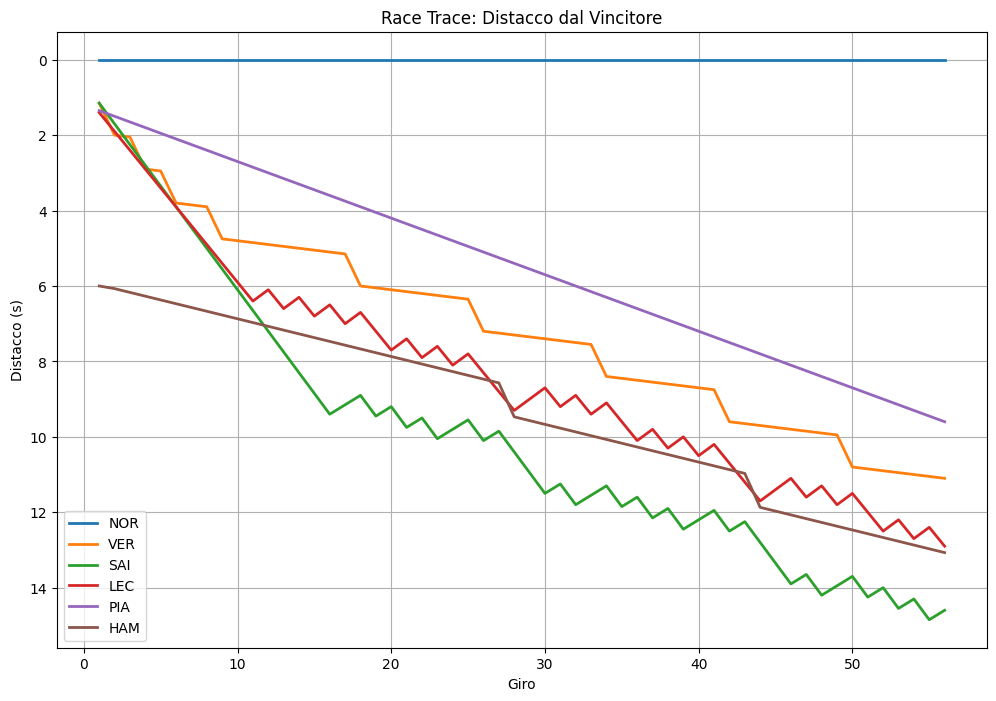

In [28]:
from src.strategy.global_simulation import GlobalRaceSimulator
import pandas as pd

from src.strategy.optimizer import StrategyOptimizer
from src.strategy.global_simulation import GlobalRaceSimulator
import pandas as pd

# 1. Inizializza l'Ottimizzatore
optimizer = StrategyOptimizer('AUSTIN')

# 2. Definisci solo i Piloti e le Macchine (Senza dire quando fermarsi!)
drivers_list = [
    {'Driver': 'NOR', 'GridPosition': 1, 'StartCompound': 'MEDIUM', 'PaceFactor': -0.15},
    {'Driver': 'VER', 'GridPosition': 2, 'StartCompound': 'MEDIUM', 'PaceFactor': -0.10}, # Degrada peggio
    {'Driver': 'SAI', 'GridPosition': 3, 'StartCompound': 'MEDIUM', 'PaceFactor': -0.40}, # Ferrari gentile su gomme
    {'Driver': 'LEC', 'GridPosition': 4, 'StartCompound': 'MEDIUM', 'PaceFactor': -0.45},
    {'Driver': 'PIA', 'GridPosition': 5, 'StartCompound': 'MEDIUM', 'PaceFactor': 0.0},
    {'Driver': 'HAM', 'GridPosition': 18, 'StartCompound': 'HARD', 'PaceFactor': -0.05} # Parte con Hard!
]

print("🧠 L'AI sta calcolando le strategie ideali pre-gara...")
grid_data = []

for d in drivers_list:
    # CHIEDI AL MODELLO: "Qual è il giro perfetto per lui?"
    optimal_lap, estimated_time = optimizer.find_optimal_strategy(d)
    
    print(f"   -> {d['Driver']} ({d['StartCompound']}): Finestra Ideale Giro {optimal_lap}")
    
    # Salvo il risultato nella griglia che userà il simulatore
    d['PitLap'] = optimal_lap
    grid_data.append(d)

grid_df = pd.DataFrame(grid_data)



# 2. Inizializza Simulatore Globale
global_sim = GlobalRaceSimulator('AUSTIN')
global_sim.initialize_grid(grid_mock)

# 3. Via alla gara!
results_df = global_sim.run_simulation()

# 4. Vediamo la classifica finale
final_standings = results_df[results_df['Lap'] == 56].sort_values('TotalTime')
print("\n🏆 CLASSIFICA FINALE SIMULATA:")
print(final_standings[['Driver', 'TotalTime', 'Tyre']])

# 5. Grafico "Gap Chart" (Tipo F1 TV)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
# Per fare il grafico dei distacchi, sottraiamo a tutti il tempo del vincitore
winner_times = results_df[results_df['Driver'] == final_standings.iloc[0]['Driver']].set_index('Lap')['TotalTime']

for drv in grid_mock['Driver']:
    drv_data = results_df[results_df['Driver'] == drv].set_index('Lap')
    # Calcolo distacco dal leader
    gap_to_leader = drv_data['TotalTime'] - winner_times
    plt.plot(drv_data.index, gap_to_leader, label=drv, linewidth=2)

plt.title("Race Trace: Distacco dal Vincitore")
plt.xlabel("Giro")
plt.ylabel("Distacco (s)")
plt.gca().invert_yaxis() # Invertiamo l'asse Y così chi sta in alto vince
plt.legend()
plt.grid(True)
plt.show()

In [29]:
# Scenario: Ferrari vuole fare Double Stack al giro 25
grid_conflict = pd.DataFrame([
    # Leclerc davanti
    {'Driver': 'LEC', 'GridPosition': 1, 'StartCompound': 'MEDIUM', 'PaceFactor': -0.45, 'PitLap': 25},
    # Sainz appena dietro (ma non abbastanza per avere spazio sicuro)
    {'Driver': 'SAI', 'GridPosition': 2, 'StartCompound': 'MEDIUM', 'PaceFactor': -0.40, 'PitLap': 25},
    # Rivali per contesto
    {'Driver': 'VER', 'GridPosition': 3, 'StartCompound': 'MEDIUM', 'PaceFactor': -0.35, 'PitLap': 26}
])

global_sim = GlobalRaceSimulator('AUSTIN')
global_sim.initialize_grid(grid_conflict)
results = global_sim.run_simulation()

🚦 Gara Inizializzata con 3 piloti.
🏁 STARTING GLOBAL SIMULATION (Stable Overtake Logic)...
🚨 SCATTATA SAFETY CAR (Giro 3)
      💰 LEC approfitta della SC (nuovo pit lap: 3)
      💰 SAI approfitta della SC (nuovo pit lap: 3)
      💰 VER approfitta della SC (nuovo pit lap: 3)
🏁 BANDIERA A SCACCHI


In [33]:
from src.data.austin_2024_pre_race import get_pre_race_data
from src.strategy.optimizer import StrategyOptimizer
from src.strategy.global_simulation import GlobalRaceSimulator

# 1. Carica lo scenario PRE-GARA
print("🔮 Caricamento dati Sabato Sera Austin 2024...")
pre_race_grid = get_pre_race_data()

# 2. L'AI decide la strategia ottimale (senza sapere il futuro!)
optimizer = StrategyOptimizer('AUSTIN')
strategies = []

print("\n🧠 Calcolo Strategie Ottimali (AI Muretto):")
for _, d in pre_race_grid.iterrows():
    # L'AI prova a fermarsi in ogni giro possibile e sceglie il migliore
    best_lap, _ = optimizer.find_optimal_strategy(d)
    d['PitLap'] = best_lap
    strategies.append(d)
    print(f"   -> {d['Driver']}: Strategia suggerita PIT al Giro {best_lap}")

# 3. Simuliamo la gara con queste strategie
sim_grid = pd.DataFrame(strategies)
simulator = GlobalRaceSimulator('AUSTIN')
simulator.initialize_grid(sim_grid)
results = simulator.run_simulation()

# 4. Grafico del Risultato Previsto
import matplotlib.pyplot as plt
# ... (codice grafico solito) ...

🔮 Caricamento dati Sabato Sera Austin 2024...

🧠 Calcolo Strategie Ottimali (AI Muretto):
   -> NOR: Strategia suggerita PIT al Giro 21
   -> VER: Strategia suggerita PIT al Giro 21
   -> SAI: Strategia suggerita PIT al Giro 21
   -> LEC: Strategia suggerita PIT al Giro 22
   -> HAM: Strategia suggerita PIT al Giro 29
🚦 Gara Inizializzata con 5 piloti.
🏁 STARTING GLOBAL SIMULATION (Fixed Overtake Logic)...



🏆 CLASSIFICA FINALE (Giro 56):
  Driver  TotalTime  GapToLeader  Tyre
0    NOR    5666.27         0.00  HARD
1    SAI    5668.07         1.80  HARD
2    LEC    5669.57         3.30  HARD
3    VER    5676.17         9.90  HARD
4    HAM    5683.04        16.77  HARD


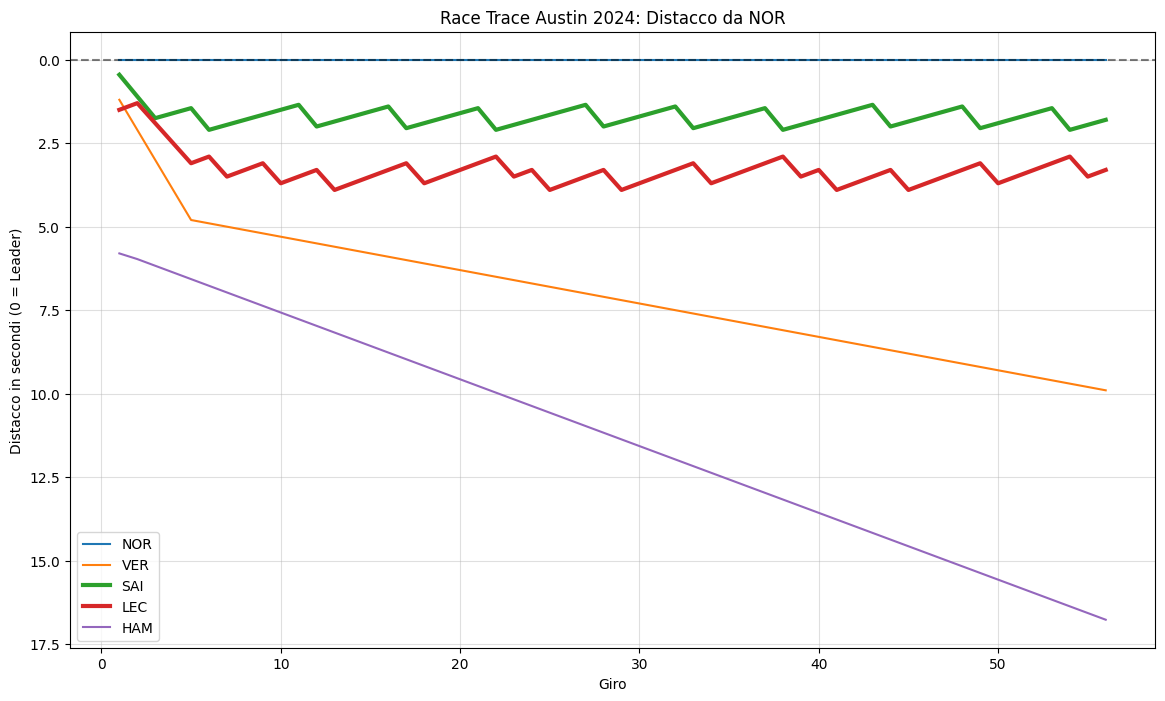

In [34]:
import matplotlib.pyplot as plt
import pandas as pd

# NOTA: Assicurati che la variabile 'results' contenga l'output della cella precedente
# (Es: results = simulator.run_simulation())
sim_results = results # Rinomino per chiarezza

# --- 1. CLASSIFICA FINALE ---
# Prendiamo l'ultimo giro (56) e ordiniamo chi ci ha messo meno tempo
final_lap = 56
final_standings = sim_results[sim_results['Lap'] == final_lap].sort_values('TotalTime')

print(f"\n🏆 CLASSIFICA FINALE (Giro {final_lap}):")
# Aggiungo una colonna "Gap dal Leader" per leggere meglio
winner_time = final_standings.iloc[0]['TotalTime']
final_standings['GapToLeader'] = final_standings['TotalTime'] - winner_time

print(final_standings[['Driver', 'TotalTime', 'GapToLeader', 'Tyre']].reset_index(drop=True))


# --- 2. GRAFICO RACE TRACE (Gap Chart) ---
plt.figure(figsize=(14, 8))

# Identifichiamo il vincitore per calcolare i distacchi relativi
winner_name = final_standings.iloc[0]['Driver']
winner_data = sim_results[sim_results['Driver'] == winner_name].set_index('Lap')['TotalTime']

drivers = sim_results['Driver'].unique()

for drv in drivers:
    # Prendo i dati del singolo pilota
    drv_data = sim_results[sim_results['Driver'] == drv].set_index('Lap')
    
    # Calcolo il Gap: (Mio Tempo - Tempo Vincitore)
    # Se sono il vincitore, sarà 0. Se sono dietro, sarà un numero positivo.
    gap_series = drv_data['TotalTime'] - winner_data
    
    # Stile: Evidenziamo le Ferrari
    lw = 3 if drv in ['LEC', 'SAI'] else 1.5
    ls = '-'
    
    plt.plot(gap_series.index, gap_series, label=drv, linewidth=lw, linestyle=ls)

# --- Estetica F1 ---
plt.title(f"Race Trace Austin 2024: Distacco da {winner_name}")
plt.xlabel("Giro")
plt.ylabel("Distacco in secondi (0 = Leader)")
plt.axhline(0, color='black', linestyle='--', alpha=0.5) # Linea del leader

# INVERTIAMO L'ASSE Y: In F1 chi sta in alto (0 gap) è primo!
plt.gca().invert_yaxis() 

plt.legend()
plt.grid(True, alpha=0.4)
plt.show()